# scalper-hft: Дослідницький інтерактивний хаб (Quantitative Research Hub)

Високочастотна алгоритмічна та кількісна дослідницька платформа для **Binance USDT-M Futures**.
Архітектура системи побудована за канонічною моделлю **Річарда Наранга** (*"Inside the Black Box"*):
$$\text{Data} \longrightarrow \text{Alpha Models} \longrightarrow \text{Risk Management} \longrightarrow \text{Transaction Costs} \longrightarrow \text{Portfolio Construction} \longrightarrow \text{Execution}$$
з інтеграцією передових методів валідації та фінансового машинного навчання **Маркоса Лопеса де Прадо** (*"Advances in Financial Machine Learning"* — AFML).

---

### Зміст дослідницького хабу:
1. **[Конфігурація та правила біржі](#1.-Конфігурація-та-правила-біржі-(Config-&-Exchange-Rules))**: комісії Maker/Taker, прослизання, відсутність lookahead.
2. **[Доступ до даних та мікроструктура ринку](#2.-Доступ-до-даних-та-мікроструктура-ринку-(Market-Data-&-Microstructure))**: Klines, Funding, CVD з aggTrades, Roll spread, Amihud, Depth5 L2 Imbalance.
3. **[Обробка сигналів, стаціонарність та ринкові режими](#3.-Обробка-сигналів,-стаціонарність-та-ринкові-режими)**: Fractional Differencing (FFD), фільтр Калмана, Half-Life, HMM / Волатильні режими.
4. **[Бектести стратегій та візуалізація](#4.-Бектести-стратегій-та-візуалізація-(Backtesting-Engine))**: порівняння Mean Reversion, Supertrend, SMC FVG з `CostModel`.
5. **[Статистичний парний арбітраж та портфельна оптимізація](#5.-Статистичний-парний-арбітраж-та-портфельна-оптимізація)**: коінтеграційний скан, Maker-виконання, Equal Risk Contribution (ERC).
6. **[Комплексний аудит на перенавчання (Anti-Overfitting Audit)](#6.-Комплексний-аудит-на-перенавчання-(Anti-Overfitting-Audit))**: Walk-Forward, Deflated Sharpe (DSR), CSCV / PBO, параметрична чутливість.
7. **[Форензіка угод та аналіз виживаності](#7.-Форензіка-угод-та-аналіз-виживаності-(Trade-Forensics-&-Survival))**: MAE/MFE аналіз збиткових угод, Kaplan-Meier тривалість позицій.
8. **[Машинне навчання та важливість фіч (AFML ML)](#8.-Машинне-навчання-та-важливість-фіч-(AFML-Machine-Learning))**: Triple-Barrier, ваги унікальності, LightGBM walk-forward, CFI, динамічний Bet Sizing.
9. **[Стрес-тести, аналіз ємності капіталу та Time-Decay](#9.-Стрес-тести,-аналіз-ємності-капіталу-та-Time-Decay)**: ринкові шоки, сатурація капіталу ($k$-impact), затримка входу (execution lag).
10. **[Асинхронна черга задач та матричний скан](#10.-Асинхронна-черга-задач-(Jobs-Queue)-та-матричний-скан)**: SQLite JobStore, фонові воркери, Matrix Sweep.
11. **[Операційна архітектура: Risk Gate, Live/Paper та Dashboard](#11.-Операційна-архітектура:-Risk-Gate,-Live/Paper-та-Веб-дашборд)**: pre-trade ліміти, Streamlit Dashboard.

> [!IMPORTANT]
> Усі дослідження в системі виконуються суворо **без lookahead-bias**: сигнал формується на барі $t$, а виконання моделюється з відкриття бару $t+1$ з обов'язковим урахуванням комісій та slippage.


## 1. Конфігурація та правила біржі (Config & Exchange Rules)

Системні параметри завантажуються з `.env` через `scalper_hft.config.get_settings()`.
Модель витрат Binance USDT-M враховує реальні комісії: Maker (Post-Only) = 0.02%, Taker (Market) = 0.05% та модельне прослизання (`slippage_frac`).


In [1]:
import logging
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Налаштування шляхів та відображення
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
logging.basicConfig(level=logging.WARNING)

from scalper_hft.config import get_settings
from scalper_hft.backtest.execution import CostModel

settings = get_settings()
cost = CostModel(
    maker_fee=settings.maker_fee,
    taker_fee=settings.taker_fee,
    slippage_frac=settings.slippage_frac
)

print("=== Системна конфігурація scalper-hft ===")
print(f"Біржа:         {settings.exchange.upper()}")
print(f"Каталог даних: {settings.data_dir_abs}")
print(f"Maker комісія: {cost.maker_fee:.4%} (0.02% для Binance USDT-M)")
print(f"Taker комісія: {cost.taker_fee:.4%} (0.05% для Binance USDT-M)")
print(f"Slippage:      {cost.slippage_frac:.4%}")
print(f"Roundtrip Taker cost: {cost.round_trip_taker():.4%}")
print(f"Roundtrip Maker cost: {cost.round_trip_maker():.4%}")


=== Системна конфігурація scalper-hft ===
Біржа:         BINANCE-TESTNET
Каталог даних: /home/volodymyr/PycharmProjects/scalper-hft/data
Maker комісія: 0.0200% (0.02% для Binance USDT-M)
Taker комісія: 0.0500% (0.05% для Binance USDT-M)
Slippage:      0.0200%
Roundtrip Taker cost: 0.1400%
Roundtrip Maker cost: 0.0400%


## 2. Доступ до даних та мікроструктура ринку (Market Data & Microstructure)

Платформа забезпечує багаторівневий доступ до ринкових даних:
1. **Klines (OHLCV)**: локальний Parquet-кеш із автоматичним ресемплінгом старших таймфреймів з 1m бази (`ensure_klines`).
2. **Funding Rates**: ставки безстрокових контрактів для carry-стратегій та корекції pnl.
3. **Order Flow (CVD)**: кумулятивна дельта об'єму агрегованих угод (`aggTrades`).
4. **HFT-мікроструктура**:
   - **Roll Spread**: непряма оцінка ефективного спреду через коваріацію різниць цін.
   - **Amihud Illiquidity**: показник відношення модулю дохідності до доларового об'єму (вплив на ціну).
   - **Corwin-Schultz Spread**: оцінка bid-ask спреду на основі High/Low за два періоди.
   - **L2 Order Book Imbalance**: зважений дисбаланс 5 рівнів книги ордерів (`BTCUSDT_depth5.parquet`).


In [2]:
from scalper_hft.data.access import ensure_klines
from scalper_hft.data.downloader import download_funding, download_agg_trades
from scalper_hft.features.indicators import cvd_from_trades
from scalper_hft.features.microstructure import roll_spread, amihud, corwin_schultz_spread
from scalper_hft.features.depth_features import depth_imbalance, depth_spread_bps

symbol = "BTCUSDT"
interval = "1h"
days = 360

# 1. Завантаження історичних свічок
df = ensure_klines(symbol, interval, days=days, base_interval="1m", derive=True)
print(f"✅ {symbol} ({interval}): {len(df):,} барів | {df.index[0]} → {df.index[-1]}")

# 2. Ставки фінансування
funding_df = download_funding(symbol, days=days)
if funding_df is not None and not funding_df.empty:
    avg_f = funding_df["fundingRate"].mean()
    ann_f = avg_f * 3 * 365 * 100
    print(f"✅ Funding Rates: {len(funding_df)} зрізів | Середня ставка: {avg_f:.6f} (річна: {ann_f:+.2f}%)")

# 3. Мікроструктурні метрики
df["roll_spread"] = roll_spread(df["close"])
df["amihud"] = amihud(df["close"], df["volume"])
df["cs_spread"] = corwin_schultz_spread(df["high"], df["low"])

# 4. Дисбаланс стакана (Depth5 L2) якщо доступний
depth_file = Path(f"data/{symbol}_depth5.parquet")
if depth_file.exists():
    depth_sample = pd.read_parquet(depth_file).tail(1000)
    depth_imb = depth_imbalance(depth_sample, levels=5)
    print(f"✅ L2 Depth5 snapshots: {len(depth_sample)} записів | Середній OBI: {depth_imb.mean():+.4f}")
else:
    depth_imb = pd.Series()
    print("ℹ L2 Depth5 файл не знайдено (накопичується фоновим bookticker_recorder)")


✅ BTCUSDT (1h): 1,441 барів | 2026-07-10 13:00:00 → 2026-09-08 13:00:00
✅ Funding Rates: 3302 зрізів | Середня ставка: 0.000067 (річна: +7.35%)
ℹ L2 Depth5 файл не знайдено (накопичується фоновим bookticker_recorder)


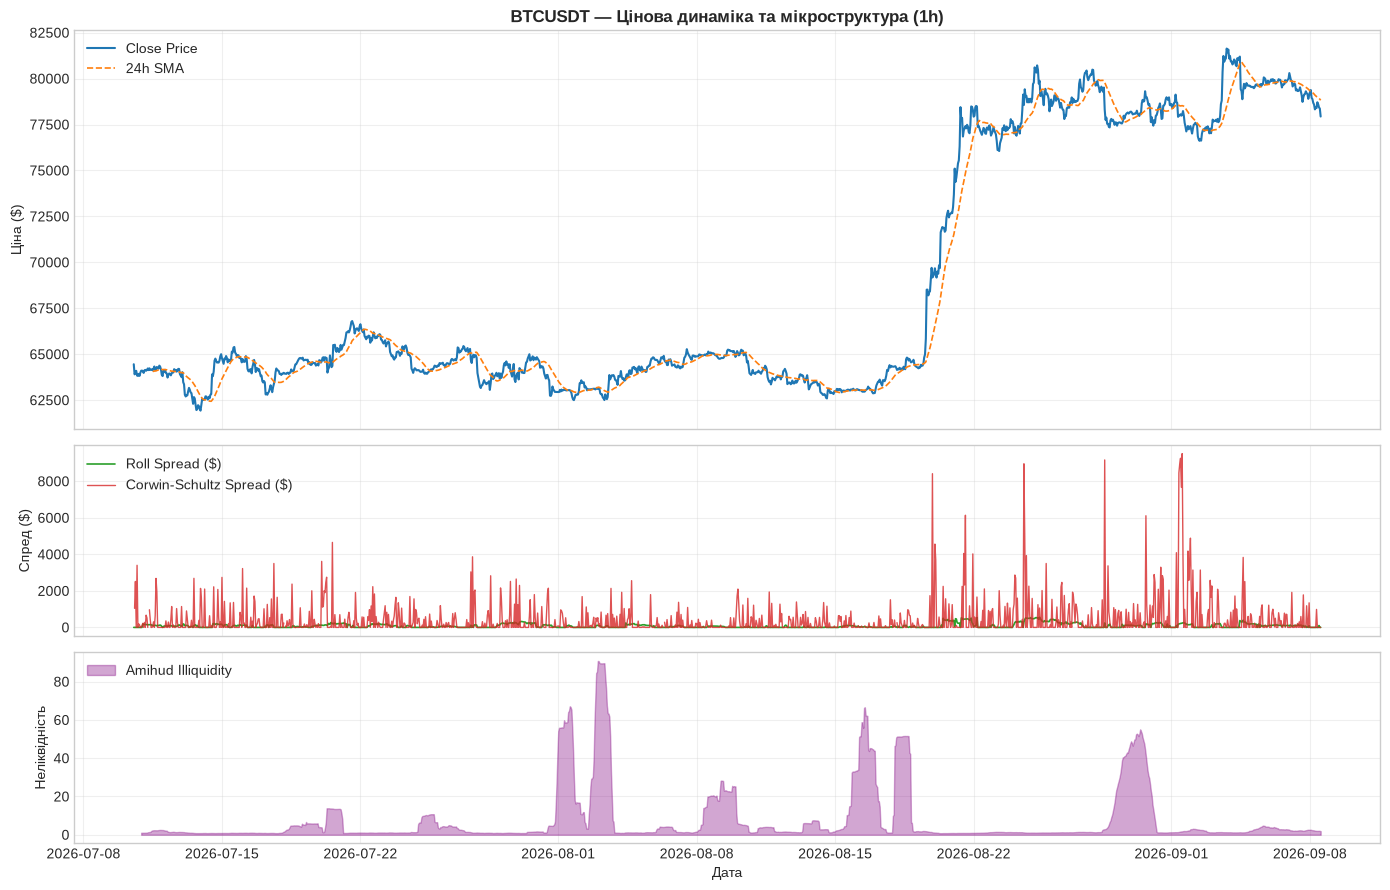

In [3]:
# Візуалізація ринкових даних та мікроструктури
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2.5, 1.2, 1.2]})

# Графік 1: Ціна закриття та ковзні середні
axes[0].plot(df.index, df["close"], label="Close Price", color="#1f77b4", lw=1.5)
axes[0].plot(df.index, df["close"].rolling(24).mean(), label="24h SMA", color="#ff7f0e", lw=1.2, ls="--")
axes[0].set_title(f"{symbol} — Цінова динаміка та мікроструктура ({interval})", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Ціна ($)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Графік 2: Roll Spread & Corwin-Schultz Spread
axes[1].plot(df.index, df["roll_spread"], label="Roll Spread ($)", color="#2ca02c", lw=1.2)
axes[1].plot(df.index, df["cs_spread"] * df["close"], label="Corwin-Schultz Spread ($)", color="#d62728", lw=1.0, alpha=0.8)
axes[1].set_ylabel("Спред ($)")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

# Графік 3: Amihud Illiquidity (вплив на ціну)
axes[2].fill_between(df.index, df["amihud"], 0, color="purple", alpha=0.35, label="Amihud Illiquidity")
axes[2].set_ylabel("Неліквідність")
axes[2].set_xlabel("Дата")
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Корисні CLI команди для роботи з даними:
# !uv run python -m scalper_hft.cli download --symbol BTCUSDT --interval 1h --days 90
# !uv run python -m scalper_hft.cli download --symbol BTCUSDT --interval 1m --days 2 --trades --trades-days 2
# !uv run python -m scalper_hft.cli download --symbol BTCUSDT --interval 1h --days 90 --funding
# !uv run python -m scalper_hft.cli record-bookticker --symbol BTCUSDT --minutes 60
# !uv run python -m scalper_hft.cli download-liquidations --symbol BTCUSDT --days 30


## 3. Обробка сигналів, стаціонарність та ринкові режими

Традиційне взяття першої різниці ($d=1$) повністю знищує довготривалу пам'ять цінового ряду, тоді як ціна ($d=0$) є нестаціонарною і призводить до хибних регресій.

В системі реалізовано:
1. **Fractional Differentiation (AFML Ch. 5)**: пошук мінімального дробового ступеня $d$ (`find_min_d`), при якому тест Дікі-Фуллера (ADF) підтверджує стаціонарність ($p < 0.05$), але зберігається максимум пам'яті.
2. **Фільтр Калмана (`apply_kalman_filter`)**: байєсівське згладжування шуму ціни в реальному часі без зсуву фази.
3. **Період напіврозпаду (`estimate_half_life`)**: визначення середнього часу повернення до середнього за процесом Орнштейна-Уленбека.
4. **Режими ринку**: детекція станів волатильності та тренду.


In [4]:
from statsmodels.tsa.stattools import adfuller
from scalper_hft.features.fractional_diff import find_min_d, frac_diff_ffd
from scalper_hft.features.signal_processing import apply_kalman_filter, estimate_half_life
from scalper_hft.features.regimes import volatility_regime

# 1. Пошук оптимального дробового d для збереження пам'яті
log_close = np.log(df["close"])
min_d = find_min_d(log_close, d_range=(0.1, 0.9), step=0.05, adf_threshold=0.05)
print(f"✅ Оптимальний ступінь фракційного диференціювання min_d = {min_d:.2f}")

# Розрахунок стаціонарного ряду FFD
df["frac_diff"] = frac_diff_ffd(log_close, d=min_d if min_d > 0 else 0.4).fillna(0.0)

# Тест ADF для трьох варіантів
p_raw = adfuller(df["close"].dropna(), maxlag=1, autolag=None)[1]
p_ret = adfuller(df["close"].pct_change().dropna(), maxlag=1, autolag=None)[1]
p_ffd = adfuller(df["frac_diff"].dropna(), maxlag=1, autolag=None)[1]

print(f"ADF p-value сирої ціни (d=0):      {p_raw:.4f} {'❌ Нестаціонарний' if p_raw > 0.05 else '✅'}")
print(f"ADF p-value дохідності (d=1):     {p_ret:.4e} ✅ Стаціонарний (втрата пам'яті)")
print(f"ADF p-value FracDiff (d={min_d:.2f}):      {p_ffd:.4e} ✅ Стаціонарний + збережена пам'ять!")

# 2. Фільтр Калмана та Half-Life
df["kalman_price"] = apply_kalman_filter(df["close"])
half_life = estimate_half_life(df["close"])
print(f"✅ Оцінка Half-Life (Ornstein-Uhlenbeck): {half_life:.1f} барів (~{half_life:.1f} годин)")

# 3. Режим волатильності
df["vol_regime"] = volatility_regime(df["close"], lookback=24)


✅ Оптимальний ступінь фракційного диференціювання min_d = 0.35
ADF p-value сирої ціни (d=0):      0.9275 ❌ Нестаціонарний
ADF p-value дохідності (d=1):     0.0000e+00 ✅ Стаціонарний (втрата пам'яті)
ADF p-value FracDiff (d=0.35):      3.6610e-01 ✅ Стаціонарний + збережена пам'ять!
✅ Оцінка Half-Life (Ornstein-Uhlenbeck): 3611.0 барів (~3611.0 годин)


/tmp/ipykernel_244661/3184364237.py:15: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_raw = adfuller(df["close"].dropna(), maxlag=1, autolag=None)[1]
/tmp/ipykernel_244661/3184364237.py:16: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_ret = adfuller(df["close"].pct_change().dropna(), maxlag=1, autolag=None)[1]
/tmp/ipykernel_244661/3184364237.py:17: FutureWarning: ad

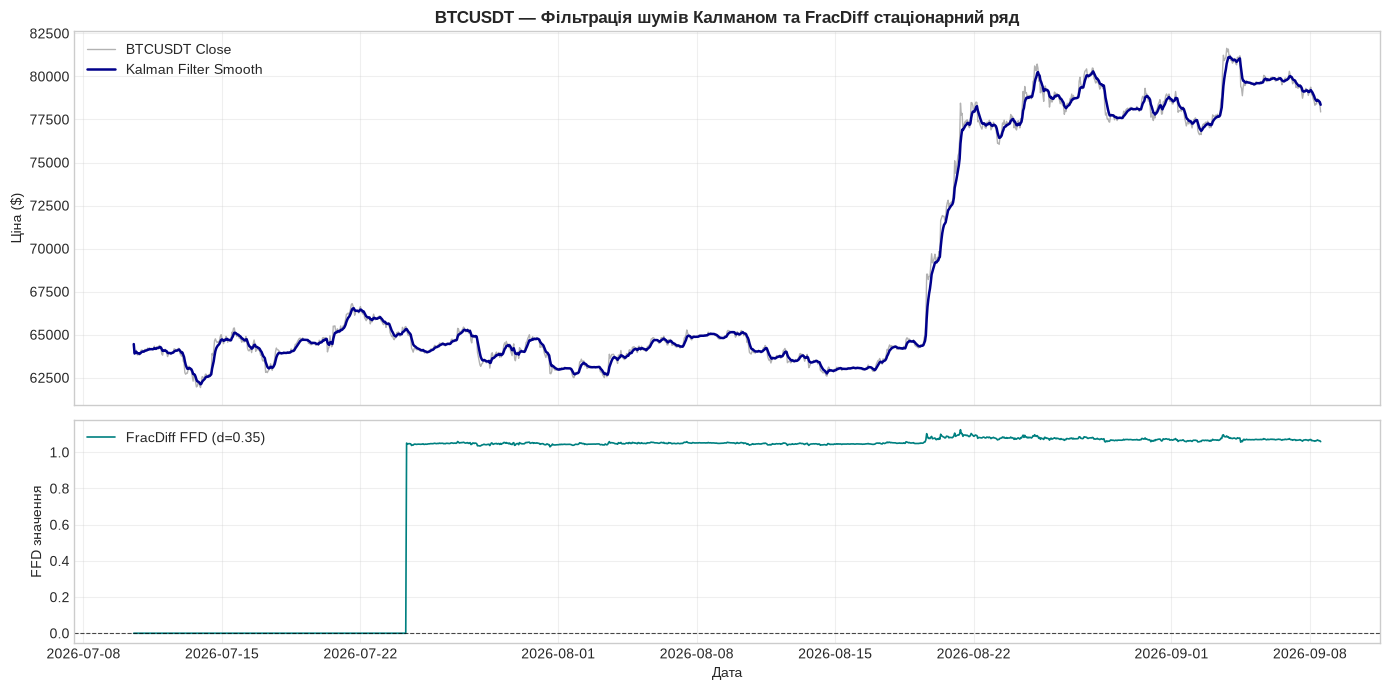

In [5]:
# Порівняння: Ціна vs Калман vs FracDiff
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]})

ax1.plot(df.index, df["close"], label="BTCUSDT Close", color="gray", alpha=0.6, lw=1)
ax1.plot(df.index, df["kalman_price"], label="Kalman Filter Smooth", color="darkblue", lw=1.8)
ax1.set_title(f"{symbol} — Фільтрація шумів Калманом та FracDiff стаціонарний ряд", fontweight="bold")
ax1.set_ylabel("Ціна ($)")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df["frac_diff"], label=f"FracDiff FFD (d={min_d:.2f})", color="teal", lw=1.2)
ax2.axhline(0, color="black", ls="--", lw=0.8, alpha=0.7)
ax2.set_ylabel("FFD значення")
ax2.set_xlabel("Дата")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Бектести стратегій та візуалізація (Backtesting Engine)

У системі зареєстровано 17 стратегій. Порівняємо 3 фундаментально різні архетипи:
1. **`mean_reversion`**: статистичне повернення до середнього за смугами Боллінджера та RSI.
2. **`supertrend`**: тренд-слідкуюча адаптивна модель на базі ATR.
3. **`smc_fvg`**: стратегія за концепцією Smart Money Concepts — заповнення дисбалансів ліквідності (Fair Value Gaps).

Бектести моделюються через `run_backtest()` з суворим дотриманням правила **t+1 execution** (без lookahead) та обліком комісій.


In [6]:
from scalper_hft.backtest.engine import run_backtest
from scalper_hft.strategies import get_strategy

# Ініціалізація стратегій
strats = {
    "Mean Reversion": get_strategy("mean_reversion", rsi_period=14, oversold=30, overbought=70, bb_period=20),
    "Supertrend": get_strategy("supertrend", atr_period=10, atr_mult=3.0),
    "SMC FVG": get_strategy("smc_fvg", max_fvg_age=12),
}

results = {}
for name, s in strats.items():
    res = run_backtest(df, s, cost=cost, position_pct=settings.position_pct)
    results[name] = res

# Порівняльна таблиця результатів
rows = []
for name, r in results.items():
    rows.append({
        "Стратегія": name,
        "Sharpe": f"{r.metrics.sharpe:.2f}",
        "Max DD": f"{r.metrics.max_drawdown:.2%}",
        "Win Rate": f"{r.metrics.win_rate:.1%}" if r.metrics.win_rate else "-",
        "Profit Factor": f"{r.metrics.profit_factor:.2f}" if r.metrics.profit_factor else "-",
        "Total Return": f"{r.metrics.total_return:.2%}",
        "Угод": r.metrics.n_trades
    })

perf_table = pd.DataFrame(rows)
print("=== Порівняння результативності стратегій ===")
display(perf_table)


=== Порівняння результативності стратегій ===


,Стратегія,Sharpe,Max DD,Win Rate,Profit Factor,Total Return,Угод
0,Mean Reversion,0.39,-0.00%,100.0%,inf,0.00%,1
1,Supertrend,-1.74,-0.05%,47.1%,0.65,-0.04%,17
2,SMC FVG,1.08,-0.11%,31.9%,1.12,0.04%,94


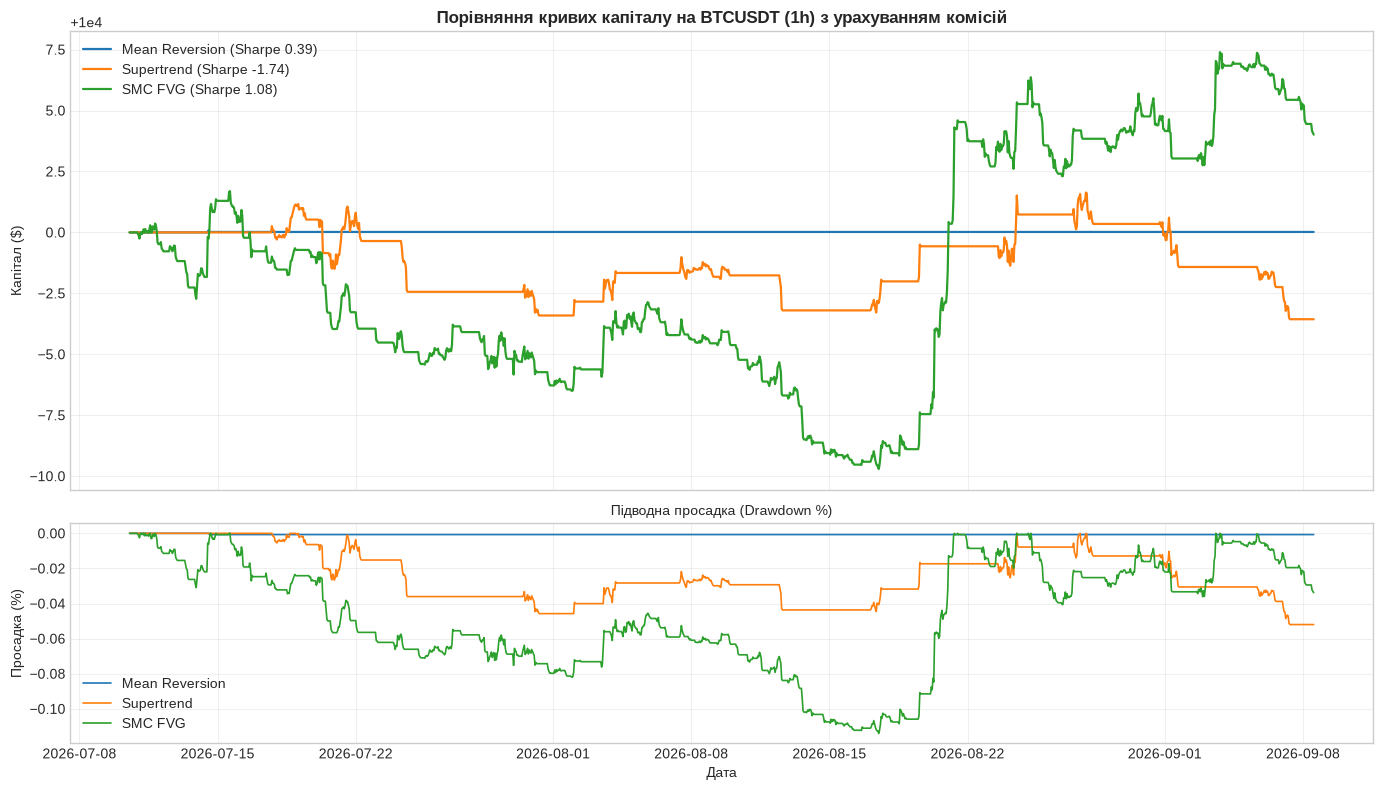

In [7]:
# Візуалізація: Криві капіталу та підводні просадки (Drawdowns)
fig, (ax_eq, ax_dd) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2.5, 1.2]})

colors = {"Mean Reversion": "#1f77b4", "Supertrend": "#ff7f0e", "SMC FVG": "#2ca02c"}

for name, r in results.items():
    ax_eq.plot(r.equity.index, r.equity, label=f"{name} (Sharpe {r.sharpe:.2f})", color=colors[name], lw=1.6)
    peak = r.equity.cummax()
    dd = (r.equity - peak) / peak
    ax_dd.plot(dd.index, dd * 100, label=name, color=colors[name], lw=1.2)

ax_eq.set_title(f"Порівняння кривих капіталу на {symbol} ({interval}) з урахуванням комісій", fontweight="bold")
ax_eq.set_ylabel("Капітал ($)")
ax_eq.legend(loc="upper left")
ax_eq.grid(True, alpha=0.3)

ax_dd.set_title("Підводна просадка (Drawdown %)", fontsize=10)
ax_dd.set_ylabel("Просадка (%)")
ax_dd.set_xlabel("Дата")
ax_dd.legend(loc="lower left")
ax_dd.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Корисні CLI команди для бектестів:
# !uv run python -m scalper_hft.cli backtest --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90
# !uv run python -m scalper_hft.cli backtest --strategy supertrend --symbol BTCUSDT --interval 1h --days 90
# !uv run python -m scalper_hft.cli backtest --strategy smc_fvg --symbol BTCUSDT --interval 1h --days 90
# !uv run python -m scalper_hft.cli plot --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --out docs/plots/bt.html


## 5. Статистичний парний арбітраж та портфельна оптимізація

Розділ демонструє:
1. **Систематичний скан коінтеграції (`scan_pairs`)**: пошук пар активів з перевіркою ADF на стаціонарність спреду та розрахунком Half-Life.
2. **Парний арбітраж з Maker-виконанням (`run_pairs_backtest`)**: дельта-нейтральна торгівля спредом через post-only лімітні ордери.
3. **Equal Risk Contribution (ERC / Risk Parity)**: портфельна алокація ваг активів/стратегій за Нарангом (гл. 6), де кожен інструмент вносить однаковий внесок у сукупний ризик портфеля.


In [8]:
from scalper_hft.validation.coint_scan import scan_pairs
from scalper_hft.backtest.pairs import run_pairs_backtest
from scalper_hft.portfolio.erc import erc_weights, risk_contributions

# 1. Завантаження кошика активів для скану коінтеграції
symbols = ["BTCUSDT", "ETHUSDT", "XRPUSDT"]
closes = {}
for s in symbols:
    d = ensure_klines(s, "1h", days=days)
    closes[s] = d["close"]

# 2. Скан пар на коінтеграцію
scan_results = scan_pairs(closes)
print("=== Результати скану коінтеграції пар ===")
for r in scan_results:
    print(r.summary())

# 3. Запуск бектесту парного арбітражу на найкращій парі
leg1, leg2 = "XRPUSDT", "BTCUSDT"
d1 = ensure_klines(leg1, "1h", days=days)
d2 = ensure_klines(leg2, "1h", days=days)
f1 = download_funding(leg1, days=days)
f2 = download_funding(leg2, days=days)

pairs_strat = get_strategy("pairs_arb", entry_z=2.0, exit_z=0.5, lookback=100)
pairs_res = run_pairs_backtest(
    d1, d2, pairs_strat, f1, f2,
    position_pct=0.1,
    cost=cost,
    maker_execution=True
)

print(f"\n=== Результати бектесту {leg1}/{leg2} (Maker execution) ===")
print(pairs_res.summary())


/home/volodymyr/PycharmProjects/scalper-hft/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Результати скану коінтеграції пар ===
ETHUSDT/XRPUSDT: ADF p=0.126 ρ=+0.69 τ=+0.52 hl=88.2 → ні
BTCUSDT/ETHUSDT: ADF p=0.300 ρ=+0.81 τ=+0.64 hl=168.2 → ні
BTCUSDT/XRPUSDT: ADF p=0.477 ρ=+0.69 τ=+0.52 hl=136.5 → ні

=== Результати бектесту XRPUSDT/BTCUSDT (Maker execution) ===
Pairs arb: ret=-0.950% | SRh=-0.013 | угод=14 | maxDD=-2.45% | funding=-0.015%
Загальна дохідність:         -0.95%
CAGR:                        -0.95%
Річна волатильність:          4.67%
Sharpe (річний):             -1.219
Sharpe (годинний):           -0.013  ← без ануалізації
Sortino:                     -1.719
Calmar:                      -0.388
Макс. просідання:            -2.45%
Win rate:                    50.00%
Profit factor:                0.548
Угоди:                           14
Середній прибуток/угода:   -0.0669%
Експозиція:                  46.56%
Угод на день:                  0.23
Turnover (зміна позиції):    2.8000
P(розорення):                1.0000


=== Порівняння алокації 1/N vs Equal Risk Contribution (ERC) ===


,Символ,Equal Weight (1/N),ERC Weight,Equal Risk Contrib,ERC Risk Contrib
0,BTCUSDT,33.3%,44.8%,22.2%,33.3%
1,ETHUSDT,33.3%,31.1%,32.7%,33.3%
2,XRPUSDT,33.3%,24.0%,45.1%,33.3%


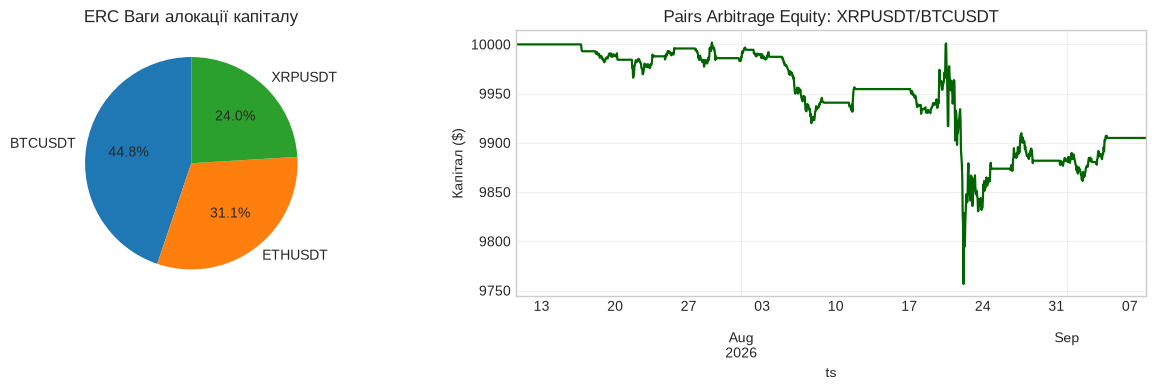

In [9]:
# 4. Equal Risk Contribution (ERC / Risk Parity) Портфельна алокація
# Матриця дохідностей активів
ret_matrix = pd.DataFrame({s: closes[s].pct_change() for s in symbols}).dropna()

# Розрахунок ERC ваг vs Рівних ваг (1/N)
w_erc = erc_weights(ret_matrix)
w_equal = np.ones(len(symbols)) / len(symbols)

rc_erc = risk_contributions(w_erc, ret_matrix.cov().values)
rc_equal = risk_contributions(w_equal, ret_matrix.cov().values)

erc_df = pd.DataFrame({
    "Символ": symbols,
    "Equal Weight (1/N)": [f"{w:.1%}" for w in w_equal],
    "ERC Weight": [f"{w:.1%}" for w in w_erc],
    "Equal Risk Contrib": [f"{rc:.1%}" for rc in rc_equal / rc_equal.sum()],
    "ERC Risk Contrib": [f"{rc:.1%}" for rc in rc_erc / rc_erc.sum()],
})
print("=== Порівняння алокації 1/N vs Equal Risk Contribution (ERC) ===")
display(erc_df)

# Графік ваг ERC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.pie(w_erc, labels=symbols, autopct="%1.1f%%", colors=["#1f77b4", "#ff7f0e", "#2ca02c"], startangle=90)
ax1.set_title("ERC Ваги алокації капіталу")

pairs_res.equity.plot(ax=ax2, color="darkgreen", lw=1.6, title=f"Pairs Arbitrage Equity: {leg1}/{leg2}")
ax2.set_ylabel("Капітал ($)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# CLI команди для парного арбітражу та портфеля:
# !uv run python -m scalper_hft.cli coint-scan --symbols BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT --interval 1h --days 90
# !uv run python -m scalper_hft.cli pairs --strategy pairs_arb --leg1 XRPUSDT --leg2 BTCUSDT --interval 1h --days 90 --maker
# !uv run python -m scalper_hft.cli pairs-portfolio --interval 1h --days 90 --maker --method erc


## 6. Комплексний аудит на перенавчання (Anti-Overfitting Audit)

За стандартами квант-фондів та **Marcos López de Prado**:
- **Walk-Forward аналіз**: перевірка чи не деградує якість на Out-of-Sample (OOS Efficiency $\ge 0.5$).
- **Deflated Sharpe Ratio (DSR)**: дисконтування коефіцієнта Шарпа з урахуванням кількості перевірених гіпотез/комбінацій ($N_{\text{trials}}$) та асиметрії розподілу (поріг $p > 0.95$).
- **CSCV / PBO**: Combinatorially Symmetric Cross-Validation для розрахунку Probability of Backtest Overfitting ($PBO < 0.50$).
- **Параметрична чутливість (Smoothness)**: перевірка наявності стійкого "плато" параметрів замість ізольованого випадкового піку.


In [ ]:
from scalper_hft.validation.walk_forward import run_walk_forward
from scalper_hft.validation.deflated_sharpe import deflated_sharpe_ratio, probabilistic_sharpe_ratio, estimate_n_trials
from scalper_hft.validation.cscv import pbo_cscv, variant_returns
from scalper_hft.validation.sensitivity import parameter_sensitivity

strat = get_strategy("mean_reversion")

# 1. Walk-Forward валідація
wf_res = run_walk_forward(df, strat, train_bars=800, test_bars=300, cost=cost)
print("=== 1. Walk-Forward Аналіз ===")
print(wf_res.summary())

# 2. Deflated Sharpe Ratio
rets = results["Mean Reversion"].equity.pct_change().dropna().values
n_trials = estimate_n_trials(len(strat.param_space), 50)
dsr = deflated_sharpe_ratio(rets, n_trials=n_trials)
psr = probabilistic_sharpe_ratio(rets, sr_benchmark=0.0)

print(f"\n=== 2. DSR / PSR Аудит (n_trials={n_trials}) ===")
print(f"Probabilistic Sharpe Ratio (PSR): {psr:.4f}")
print(f"Deflated Sharpe Ratio (DSR):      {dsr:.4f}")
print("Вердикт DSR: " + ("✅ СТАТИСТИЧНО ЗНАЧУЩИЙ EDGE (DSR > 0.95)" if dsr > 0.95 else "❌ ВИСОКИЙ РИЗИК ПЕРЕНАВЧАННЯ (DSR <= 0.95)"))

# 3. CSCV / PBO
print("\n=== 3. Combinatorially Symmetric Cross-Validation (CSCV / PBO) ===")
try:
    v_rets = variant_returns(df, strat, n_variants=15, cost=cost, seed=42)
    cscv_res = pbo_cscv(v_rets, n_blocks=8, max_combos=70)
    print(cscv_res.summary())
except Exception as e:
    print(f"Примітка щодо CSCV: {e}")

# 4. Параметрична чутливість (Smoothness Plateau)
print("\n=== 4. Аналіз параметричної гладкості (Sensitivity) ===")
sens = parameter_sensitivity(df, strat, "oversold", [20.0, 25.0, 30.0, 35.0, 40.0], cost=cost)
print(sens.summary())


In [ ]:
# Графік параметричної чутливості (плато vs пік)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sens.grid["oversold"], sens.grid["metric"], marker="o", lw=2, color="#1f77b4")
ax.set_title(f"Параметрична чутливість RSI Oversold (Гладкість плато = {sens.smoothness:.2f})", fontweight="bold")
ax.set_xlabel("Значення параметра (oversold)")
ax.set_ylabel("Sharpe Ratio")
ax.grid(True, alpha=0.3)
plt.show()


In [ ]:
# CLI команди повного аудиту на перенавчання:
# !uv run python -m scalper_hft.cli overfit --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --trials 50
# !uv run python -m scalper_hft.cli cscv --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --variants 30 --blocks 8
# !uv run python -m scalper_hft.cli report --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90


## 7. Форензіка угод та аналіз виживаності (Trade Forensics & Survival)

Аналіз угод розділяє фундаментальні проблеми входу від проблем виходу:
- **MAE (Maximum Adverse Excursion)**: максимальний несприятливий рух ціни проти позиції за час її утримання. Допомагає встановити оптимальний рівень стоп-лосу.
- **MFE (Maximum Favorable Excursion)**: максимальний сприятливий рух на користь позиції. Виявляє запізнілі виходи ("прибуток був у кишені, але повернувся в нуль/мінус").
- **Аналіз виживаності Каплана-Мейєра (`kaplan_meier`)**: моделює криву тривалості життя угоди.


In [ ]:
from scalper_hft.validation.forensics import analyze_trades, excursions_from_bars
from scalper_hft.validation.survival import kaplan_meier, trade_durations

trades = results["Mean Reversion"].trades
if trades is not None and not trades.empty:
    # 1. Розрахунок MFE / MAE за барами
    trades_with_excursions = excursions_from_bars(trades, df)
    forensics = analyze_trades(trades_with_excursions)
    print("=== Звіт форензіки угод (Loss Forensics) ===")
    print(forensics.summary())

    # 2. Графік MFE vs MAE
    if "mfe" in trades_with_excursions.columns and "mae" in trades_with_excursions.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        winners = trades_with_excursions[trades_with_excursions["ret"] > 0]
        losers = trades_with_excursions[trades_with_excursions["ret"] <= 0]
        
        ax1.scatter(winners["mae"] * 100, winners["mfe"] * 100, color="green", alpha=0.7, label="Прибуткові (Winners)")
        ax1.scatter(losers["mae"] * 100, losers["mfe"] * 100, color="red", alpha=0.7, label="Збиткові (Losers)")
        ax1.set_xlabel("MAE — Max Adverse Excursion (%)")
        ax1.set_ylabel("MFE — Max Favorable Excursion (%)")
        ax1.set_title("MFE vs MAE Розподіл угод", fontweight="bold")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 3. Крива виживаності Каплана-Мейєра
        dur = (pd.to_datetime(trades["exit_ts"]) - pd.to_datetime(trades["entry_ts"])).dt.total_seconds() / 3600
        events = np.ones(len(dur))
        km = kaplan_meier(dur.values, events)
        
        ax2.step(km["timeline"], km["survival"], where="post", color="purple", lw=1.8)
        ax2.set_xlabel("Тривалість утримання (годин)")
        ax2.set_ylabel("Ймовірність виживання угоди")
        ax2.set_title("Крива виживаності Каплана-Мейєра", fontweight="bold")
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
else:
    print("В бектесті недостатньо угод для форензіки (збільшіть тестовий період)")


## 8. Машинне навчання та важливість фіч (AFML Machine Learning)

Побудова градієнтного бустингу **LightGBM** за фінансовими принципами Маркоса Лопеса де Прадо:
1. **Triple-Barrier Labeling (`build_labeled_dataset`)**: динамічні таргети (тейк-профіт, стоп-лосс на базі волатильності, вертикальний часовий бар'єр).
2. **AFML Sample Weights**: розрахунок унікальності зразків (`get_avg_uniqueness`) для вилучення взаємозалежності через перекриття угод.
3. **Walk-Forward LightGBM (`train_walk_forward`)**: навчання з очищенням та ембарго без підглядання вперед.
4. **Важливість фіч (Feature Importance)**: MDI / MDA аналіз найефективніших факторів.
5. **Динамічний Bet Sizing (`prob_to_size`)**: перетворення передбаченої моделі ймовірності в безперервний розмір позиції.


In [ ]:
from scalper_hft.ml.features import build_labeled_dataset
from scalper_hft.ml.trainer import train_walk_forward
from scalper_hft.ml.bet_sizing import prob_to_size, sigmoid_size

print("=== 1. Побудова Triple-Barrier датасету ===")
# Генерація датасету фіч із дробовим диференціюванням та потрійним бар'єром
X, y, w = build_labeled_dataset(
    df.head(500),
    mode="triple_barrier",
    pt=1.0,
    sl=1.0,
    holding_bars=12,
    add_frac_diff=True,
    add_micro=False
)
print(f"Розмірність матриці фіч: X={X.shape} | Лейбли: y={dict(y.value_counts())}")

print("\n=== 2. Walk-Forward Навчання LightGBM з AFML вагами ===")
try:
    ml_res = train_walk_forward(
        X, y,
        train_size=200,
        test_size=50,
        close=df["close"].loc[X.index],
        sample_weights=w
    )
    print(ml_res.summary())
    
    # 3. Візуалізація важливості фіч (Top 10 Feature Importance)
    if ml_res.feature_importance is not None and not ml_res.feature_importance.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        top_feats = ml_res.feature_importance.head(10).sort_values()
        top_feats.plot(kind="barh", ax=ax1, color="teal")
        ax1.set_title("LightGBM Feature Importance (MDI / Gain)", fontweight="bold")
        ax1.set_xlabel("Важливість фічі")
        ax1.grid(True, alpha=0.3)
        
        # 4. Динамічний Bet Sizing (Sigmoid Bet Curve)
        p_grid = np.linspace(0.0, 1.0, 100)
        sizes = prob_to_size(p_grid, method="logit")
        ax2.plot(p_grid, sizes, color="crimson", lw=2)
        ax2.axvline(0.5, color="black", ls="--", lw=0.8)
        ax2.axhline(0, color="black", ls="--", lw=0.8)
        ax2.set_title("Динамічний Bet Sizing від ймовірності моделі P(win)", fontweight="bold")
        ax2.set_xlabel("Прогнозована ймовірність P(y=1)")
        ax2.set_ylabel("Масштаб позиції (Bet Size ∈ [-1, 1])")
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"ML навчання пропущено або виникла помилка: {e}")


In [ ]:
# CLI команди ML та аналізу фіч:
# !uv run python -m scalper_hft.cli ml --symbol BTCUSDT --interval 5m --days 30 --pt 1.0 --sl 1.0 --holding 10
# !uv run python -m scalper_hft.cli featimp --symbol BTCUSDT --interval 5m --days 30 --splits 4
# !uv run python -m scalper_hft.cli cfi --symbol BTCUSDT --interval 5m --days 30 --max-clusters 6
# !uv run python -m scalper_hft.cli lift --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --bins 10 --top 10


## 9. Стрес-тести, аналіз ємності капіталу та Time-Decay

Перевірка стійкості альфи до ринкових шоків та реальних торговельних обмежень:
1. **Стрес-тести (`stress_test`)**: симуляція сценаріїв ринкового краху (Crash), заморозки ліквідності (Liquidity freeze), сплеску волатильності (Vol spike) та шоку фінансування.
2. **Ємність капіталу (`capacity_curve`)**: моделювання деградації Sharpe при зростанні торгового капіталу за рахунок квадратичного впливу на ринок ($k$-market impact).
3. **Time-Decay аналіз (`time_decay_test`)**: оцінка падіння прибутковості при затримці виконання на 1, 2, 3 бари.


In [ ]:
from scalper_hft.validation.stress import stress_test
from scalper_hft.validation.capacity import capacity_curve
from scalper_hft.validation.time_decay import time_decay_test

strat = get_strategy("mean_reversion")

# 1. Стрес-тестування
stress_results = stress_test(results["Mean Reversion"].returns)
print("=== 1. Результати стрес-тестування за сценаріями ===")
for sc, ret_series in stress_results.items():
    sc_sharpe = (ret_series.mean() / ret_series.std() * np.sqrt(365 * 24)) if ret_series.std() > 0 else 0.0
    print(f"Сценарій {sc:15}: Sharpe = {sc_sharpe:+.2f}")

# 2. Аналіз ємності капіталу (Capacity Curve)
cap_curve = capacity_curve(df, strat, scales=[1, 2, 5, 10, 20], cost=cost)
print("\n=== 2. Крива ємності капіталу (Масштабування vs Sharpe) ===")
display(cap_curve[["scale", "sharpe", "total_cost", "trades"]].head())

# 3. Time-Decay (деградація при затримці виконання)
td_res = time_decay_test(df, strat, max_lag=3, cost=cost)
print(f"\n=== 3. Time-Decay тест затримки виконання ===")
for lag, s_val in td_res.sharpes.items():
    print(f"Лаг {lag} барів: Sharpe = {s_val:.2f}")


In [ ]:
# Візуалізація: Ємність капіталу та Time-Decay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(cap_curve["scale"], cap_curve["sharpe"], marker="s", color="darkred", lw=2)
ax1.set_title("Крива ємності: Залежність Sharpe від масштабу капіталу", fontweight="bold")
ax1.set_xlabel("Масштаб капіталу (множник)")
ax1.set_ylabel("Sharpe Ratio")
ax1.grid(True, alpha=0.3)

lags = list(td_res.sharpes.keys())
sharpes = list(td_res.sharpes.values())
ax2.bar([f"Лаг {l}" for l in lags], sharpes, color="#1f77b4", alpha=0.8, width=0.5)
ax2.set_title("Time-Decay: Втрата альфи при затримці виконання", fontweight="bold")
ax2.set_ylabel("Sharpe Ratio")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# CLI команди стрес-тестів та ємності:
# !uv run python -m scalper_hft.cli stress --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 180 --scenarios crash,liquidity,vol_spike,funding_shock
# !uv run python -m scalper_hft.cli capacity --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --scales 1,2,5,10,20 --maker
# !uv run python -m scalper_hft.cli time-decay --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --max-lag 3
# !uv run python -m scalper_hft.cli survival --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90


## 10. Асинхронна черга задач (Jobs Queue) та матричний скан

Система scalper-hft підтримує асинхронну чергу задач на **SQLite** (`results/jobs.sqlite`).
Задачі ставляться миттєво з дедуплікацією за хешем конфігурації, а фонові воркери (`uv run python -m scalper_hft.cli job worker`) обробляють чергу паралельно.

**Matrix Sweep**: паралельний прогін по сітці (Стратегії × Символи × Таймфрейми).


In [ ]:
from scalper_hft.research.jobs import JobStore

with JobStore() as store:
    jobs = store.list_jobs(limit=10)
    worker_alive = store.worker_is_alive()
    print(f"Статус фонового воркера: {'🟢 ЖИВИЙ' if worker_alive else '🔴 НЕ ЗАПУЩЕНИЙ'}")
    if jobs:
        data = [
            {
                "ID": j.id,
                "Тип": j.kind,
                "Статус": j.status,
                "Хеш": j.short_fp,
                "Прогрес": f"{j.progress_done}/{j.progress_total}" if j.progress_total else "-",
                "Помилка": (j.error or "")[:40],
            }
            for j in jobs
        ]
        display(pd.DataFrame(data))
    else:
        print("Черга задач наразі порожня.")


In [ ]:
# Управління чергою задач та воркерами:
# 1. Поставити бектест у чергу (миттєве повернення):
# !uv run python -m scalper_hft.cli backtest --strategy mean_reversion --symbol BTCUSDT --interval 1h --days 90 --enqueue

# 2. Поставити матричний скан у чергу:
# !uv run python -m scalper_hft.cli sweep --symbols BTCUSDT,ETHUSDT,SOLUSDT --intervals 15m,1h --days 60 --workers 4 --enqueue

# 3. Запустити фонового воркера для обробки черги:
# !uv run python -m scalper_hft.cli job worker --jobs 2

# 4. Список задач у черзі:
# !uv run python -m scalper_hft.cli job list


## 11. Операційна архітектура: Risk Gate, Live/Paper та Веб-дашборд

Перед виконанням реальних ордерів система пропускає кожен торговий сигнал через багатошаровий захист:
1. **Pre-Trade Risk Gate (`decide_entry`)**: перевірка максимального плеча, корельованого розміру позицій, обмеження одночасного ризику та cooldown після збитків.
2. **Control State (`ControlState`)**: аварійний kill-switch, контроль денного ліміту просадки, режим `DRY_RUN=true`.
3. **Streamlit Web Dashboard**: повнофункціональний веб-інтерфейс для моніторингу бектестів, результатів аудиту та живого стану торгових воркерів.


In [ ]:
from scalper_hft.live.control import ControlState, load_control
from scalper_hft.live.risk_gate import decide_entry, CooldownState

# 1. Стан операційного контролю
ctrl = load_control()
print("=== Стан операційного контролю (ControlState) ===")
print(f"Аварійний Kill-Switch (paused):  {'🔴 АКТИВОВАНО' if ctrl.paused else '🟢 ВИМКНЕНО (Торгівля дозволена)'}")
print(f"Торговий режим:                  {ctrl.mode.upper()}")
print(f"Максимальна просадка:            {ctrl.max_drawdown:.1%}")

# 2. Risk Gate перевірка на вхід
decision = decide_entry(
    pair_id="BTCUSDT",
    side=1,
    size_pct=0.05,
    open_positions={"ETHUSDT": 0.05},
    cooldown=CooldownState(),
    max_portfolio_size_pct=0.30
)
print(f"\n=== Risk Gate Рішення для BTCUSDT (Long 5%) ===")
print(f"Дозволено: {decision.allowed} | Причина: {decision.reason or 'Усі ризик-ліміти в нормі'}")
print(f"Скоригований розмір: {decision.adjusted_size_pct:.1%}")


In [ ]:
# Запуск інтерактивного Streamlit Веб-дашборду:
# !uv run python -m scalper_hft.dashboard
# або у фоновому режимі:
# !nohup uv run python -m scalper_hft.dashboard --server.port 8501 > dashboard.log 2>&1 &
print("🌐 Веб-дашборд доступний за адресою: http://localhost:8501")
